# Evaluation Slice Visualisation

This notebook compares evaluation JSON files under `runs/` and visualises the slice families that help developers understand where the model performs well or poorly. By default it compares the strongest MiniLM and MPNet candidate-attention rankers on the same Large Temporal Val protocol:

- `impressions_with_clicked_category`
- `impressions_with_clicked_subcategory`
- `impressions_with_clicked_popularity_bucket`
- `history_len_bucket`
- cold/warm user state
- new/warm clicked-item state
- `time_period`

Every plotted series includes its run name, stage, and split so unrelated experiments cannot be silently averaged together. The notebook plots available model metrics such as `auc` and `ndcg@10`; retrieval recall at the exact configured cutoff, for example `Recall@200`, remains available when retrieval files are selected.

In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 21,
    "axes.labelsize": 17,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 14,
})
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)

## Configuration

The defaults compare the two strongest directly comparable Large Temporal Val rankers: MiniLM candidate attention and MPNet candidate attention. Adjust `SELECTED_RUNS`, `INCLUDE_STAGES`, `INCLUDE_SPLITS`, or `METRICS_TO_PLOT` for another controlled comparison. Set `SELECTED_RUNS = None` to scan every run, but compare metrics only when their split protocols match.

In [2]:
ROOT = Path.cwd()
if not (ROOT / "runs").exists() and (ROOT.parent / "runs").exists():
    ROOT = ROOT.parent

RUNS_ROOT = ROOT / "runs"
EVAL_GLOBS = ["*/eval/*.json", "*/retrieval/eval_*.json"]

RUN_LABELS = {
    "mind_large_temporal_text_adapt_candidate_attention_v1": "MiniLM candidate attention",
    "mind_large_temporal_mpnet_candidate_attention_v1": "MPNet candidate attention",
}
SELECTED_RUNS: list[str] | None = list(RUN_LABELS)
INCLUDE_STAGES: set[str] | None = {"ranker_eval"}
INCLUDE_SPLITS: set[str] | None = {"val"}

SLICE_PREFIXES = {
    "clicked_category": "impressions_with_clicked_category__",
    "clicked_subcategory": "impressions_with_clicked_subcategory__",
    "clicked_popularity_bucket": "impressions_with_clicked_popularity_bucket__",
    "history_len_bucket": "history_len_bucket__",
    "time_period": "time_period__",
}

EXACT_SLICES = {
    "cold_user": ("user_state", "cold"),
    "warm_user": ("user_state", "warm"),
    "impressions_with_clicked_new_item": ("clicked_item_state", "new"),
    "impressions_with_clicked_warm_item": ("clicked_item_state", "warm"),
}
SLICE_DIMENSIONS = [*SLICE_PREFIXES, "user_state", "clicked_item_state"]

# Add "recall@10", "mrr", or "recall_at_k" for a deeper diagnostic pass.
METRICS_TO_PLOT = ["auc", "ndcg@10"]
TOP_N_CATEGORIES = 12
TOP_N_SUBCATEGORIES = 15
MIN_IMPRESSIONS_FOR_METRIC_PLOTS = 1_000

RUNS_ROOT

WindowsPath('c:/Users/abiga/OneDrive/Documents/MIND_Multistage_Recommender_with_Knowledge_Graph/runs')

## Load And Tidy Eval Slices

The loader keeps only selected JSON files with a top-level `slices` object. Files like rerank search summaries remain discoverable in the folder but are skipped unless they contain compatible slice metrics. Run-aware labels prevent separate experiments from collapsing into a single averaged series.

In [3]:
def read_json(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def infer_eval_metadata(path: Path, payload: dict) -> dict:
    rel = path.relative_to(ROOT)
    parts = rel.parts
    run_name = parts[1] if len(parts) > 1 and parts[0] == "runs" else parts[0]
    stage = "retrieval" if "retrieval" in parts else "ranker_eval" if path.name.startswith("ranker_eval") else "eval"
    split = payload.get("eval_split")
    if not split:
        match = re.search(r"_(val|test|train)\.json$", path.name)
        split = match.group(1) if match else path.stem
    stage_label = {"retrieval": "Retrieval", "ranker_eval": "Ranker", "eval": "Eval"}.get(stage, stage.replace("_", " ").title())
    split_label = str(split).replace("_", " ").title()
    run_label = RUN_LABELS.get(run_name, run_name)
    label = f"{run_label} | {stage_label} | {split_label}"
    return {"path": str(rel), "run": run_name, "run_label": run_label, "stage": stage, "split": split, "file_label": label, "eval_k": payload.get("k")}


def parse_slice_key(key: str) -> tuple[str | None, str | None]:
    if key in EXACT_SLICES:
        return EXACT_SLICES[key]
    for dimension, prefix in SLICE_PREFIXES.items():
        if key.startswith(prefix):
            return dimension, key[len(prefix):]
    return None, None


def discover_eval_jsons() -> list[Path]:
    paths = []
    for pattern in EVAL_GLOBS:
        paths.extend(RUNS_ROOT.glob(pattern))
    if SELECTED_RUNS is not None:
        selected = set(SELECTED_RUNS)
        paths = [path for path in paths if path.relative_to(RUNS_ROOT).parts[0] in selected]
    return sorted(set(paths))


def build_slice_frame(paths: list[Path]) -> tuple[pd.DataFrame, pd.DataFrame]:
    records = []
    file_records = []

    for path in paths:
        payload = read_json(path)
        meta = infer_eval_metadata(path, payload)
        if INCLUDE_STAGES is not None and meta["stage"] not in INCLUDE_STAGES:
            continue
        if INCLUDE_SPLITS is not None and meta["split"] not in INCLUDE_SPLITS:
            continue
        slices = payload.get("slices", {})
        has_supported_slices = isinstance(slices, dict) and any(parse_slice_key(k)[0] for k in slices)
        file_records.append({**meta, "has_supported_slices": has_supported_slices, "n_slices": len(slices) if isinstance(slices, dict) else 0})
        if not has_supported_slices:
            continue

        overall = slices.get("overall", {})
        overall_n = overall.get("n_impressions")
        time_period_lookup = {p.get("name"): p for p in payload.get("time_periods", []) if isinstance(p, dict)}

        for slice_key, metrics in slices.items():
            dimension, value = parse_slice_key(slice_key)
            if dimension is None or not isinstance(metrics, dict):
                continue
            record = {
                **meta,
                "slice_key": slice_key,
                "dimension": dimension,
                "value": value,
                "n_impressions": metrics.get("n_impressions", np.nan),
                "overall_n_impressions": overall_n,
            }
            if dimension == "time_period":
                period = time_period_lookup.get(value, {})
                record["time_min"] = period.get("time_min")
                record["time_max"] = period.get("time_max")
            for metric_name, metric_value in metrics.items():
                if metric_name != "n_impressions" and isinstance(metric_value, (int, float)):
                    record[metric_name] = metric_value
            records.append(record)

    df = pd.DataFrame(records)
    files = pd.DataFrame(file_records)
    if not df.empty:
        df["support_share"] = df["n_impressions"] / df["overall_n_impressions"]
        if "time_min" in df and "time_max" in df:
            df["time_min"] = pd.to_datetime(df["time_min"], errors="coerce")
            df["time_max"] = pd.to_datetime(df["time_max"], errors="coerce")
            df["time_mid"] = df["time_min"] + (df["time_max"] - df["time_min"]) / 2
    if not files.empty and files["file_label"].duplicated().any():
        duplicates = files.loc[files["file_label"].duplicated(keep=False), "file_label"].tolist()
        raise ValueError(f"Evaluation labels must be unique; duplicate labels: {duplicates}")
    return df, files


slice_df, file_df = build_slice_frame(discover_eval_jsons())
display(file_df)
display(slice_df.head())

,path,run,run_label,stage,split,file_label,eval_k,has_supported_slices,n_slices
0,runs\mind_large_temporal_mpnet_candidate_attention_v1\eval\ranker_eval_val.json,mind_large_temporal_mpnet_candidate_attention_v1,MPNet candidate attention,ranker_eval,val,MPNet candidate attention | Ranker | Val,None,True,214
1,runs\mind_large_temporal_text_adapt_candidate_attention_v1\eval\ranker_eval_val.json,mind_large_temporal_text_adapt_candidate_attention_v1,MiniLM candidate attention,ranker_eval,val,MiniLM candidate attention | Ranker | Val,None,True,214


,path,run,run_label,stage,split,file_label,eval_k,slice_key,dimension,value,n_impressions,overall_n_impressions,ndcg@5,ndcg@10,recall@5,recall@10,map@5,map@10,mrr,auc,time_min,time_max,support_share,time_mid
0,runs\mind_large_temporal_mpnet_candidate_attention_v1\eval\ranker_eval_val.json,mind_large_temporal_mpnet_candidate_attention_v1,MPNet candidate attention,ranker_eval,val,MPNet candidate attention | Ranker | Val,None,warm_user,user_state,warm,698541,807988,0.375204,0.435518,0.512772,0.683221,0.310155,0.337445,0.338560,0.697192,NaT,NaT,0.864544,NaT
1,runs\mind_large_temporal_mpnet_candidate_attention_v1\eval\ranker_eval_val.json,mind_large_temporal_mpnet_candidate_attention_v1,MPNet candidate attention,ranker_eval,val,MPNet candidate attention | Ranker | Val,None,history_len_bucket__21_plus,history_len_bucket,21_plus,388845,807988,0.369849,0.432381,0.499255,0.673678,0.302618,0.331230,0.329462,0.709331,NaT,NaT,0.481251,NaT
2,runs\mind_large_temporal_mpnet_candidate_attention_v1\eval\ranker_eval_val.json,mind_large_temporal_mpnet_candidate_attention_v1,MPNet candidate attention,ranker_eval,val,MPNet candidate attention | Ranker | Val,None,time_period__period_3_of_4,time_period,period_3_of_4,201997,807988,0.390406,0.449890,0.536602,0.705038,0.323989,0.351076,0.351012,0.686420,2019-11-14 19:08:04,2019-11-15 09:21:47,0.250000,2019-11-15 02:14:55.500
3,runs\mind_large_temporal_mpnet_candidate_attention_v1\eval\ranker_eval_val.json,mind_large_temporal_mpnet_candidate_attention_v1,MPNet candidate attention,ranker_eval,val,MPNet candidate attention | Ranker | Val,None,impressions_with_clicked_new_item,clicked_item_state,new,686516,807988,0.371071,0.434872,0.512893,0.692874,0.303978,0.332873,0.333240,0.704677,NaT,NaT,0.849661,NaT
4,runs\mind_large_temporal_mpnet_candidate_attention_v1\eval\ranker_eval_val.json,mind_large_temporal_mpnet_candidate_attention_v1,MPNet candidate attention,ranker_eval,val,MPNet candidate attention | Ranker | Val,None,impressions_with_clicked_popularity_bucket__0,clicked_popularity_bucket,0,527143,807988,0.365262,0.428753,0.504081,0.682193,0.297818,0.326678,0.326387,0.691061,NaT,NaT,0.652414,NaT


## Overview Tables

These tables show which slice dimensions and metrics were found before plotting.

In [4]:
if slice_df.empty:
    raise ValueError(f"No supported slice metrics found under {RUNS_ROOT}")

metric_cols = [
    c for c in slice_df.columns
    if c not in {"path", "run", "run_label", "stage", "split", "file_label", "eval_k", "slice_key", "dimension", "value", "n_impressions", "overall_n_impressions", "support_share", "time_min", "time_max", "time_mid"}
    and pd.api.types.is_numeric_dtype(slice_df[c])
]

coverage = (
    slice_df.groupby(["file_label", "dimension"])
    .agg(n_slices=("slice_key", "nunique"), total_slice_impressions=("n_impressions", "sum"))
    .reset_index()
    .sort_values(["file_label", "dimension"])
)

metric_availability = (
    slice_df.groupby("file_label")[metric_cols]
    .apply(lambda g: g.notna().sum())
    .reset_index()
)

display(coverage)
display(metric_availability)

,file_label,dimension,n_slices,total_slice_impressions
0,MPNet candidate attention | Ranker | Val,clicked_category,14,1114694
1,MPNet candidate attention | Ranker | Val,clicked_item_state,2,890174
2,MPNet candidate attention | Ranker | Val,clicked_popularity_bucket,4,954278
3,MPNet candidate attention | Ranker | Val,clicked_subcategory,183,1192716
4,MPNet candidate attention | Ranker | Val,history_len_bucket,4,807988
5,MPNet candidate attention | Ranker | Val,time_period,4,807988
6,MPNet candidate attention | Ranker | Val,user_state,2,807988
7,MiniLM candidate attention | Ranker | Val,clicked_category,14,1114694
8,MiniLM candidate attention | Ranker | Val,clicked_item_state,2,890174
9,MiniLM candidate attention | Ranker | Val,clicked_popularity_bucket,4,954278


,file_label,ndcg@5,ndcg@10,recall@5,recall@10,map@5,map@10,mrr,auc
0,MPNet candidate attention | Ranker | Val,213,213,213,213,213,213,213,213
1,MiniLM candidate attention | Ranker | Val,213,213,213,213,213,213,213,213


## Plot Helpers

In [5]:
DIMENSION_LABELS = {
    "clicked_category": "Clicked Category",
    "clicked_subcategory": "Clicked Subcategory",
    "clicked_popularity_bucket": "Clicked Item Popularity",
    "history_len_bucket": "History Len Bucket",
    "user_state": "User State",
    "clicked_item_state": "Clicked Item State",
    "time_period": "Time Period",
}

METRIC_LABELS = {
    "ndcg@5": "nDCG@5",
    "ndcg@10": "nDCG@10",
    "recall@5": "Recall@5",
    "recall@10": "Recall@10",
    "recall_at_k": "Recall@K",
    "auc": "AUC",
    "mrr": "MRR",
}


def dimension_label(dimension: str) -> str:
    return DIMENSION_LABELS.get(dimension, str(dimension).replace("_", " ").title())


def metric_label(metric: str, data: pd.DataFrame | None = None) -> str:
    if metric == "recall_at_k" and data is not None and "eval_k" in data:
        ks = sorted({int(k) for k in data["eval_k"].dropna().unique()})
        if len(ks) == 1:
            return f"Recall@{ks[0]}"
        if len(ks) > 1:
            return "Recall@K"
    return METRIC_LABELS.get(metric, metric)


def pretty_value(value: str, dimension: str | None = None) -> str:
    value = str(value)
    if dimension == "history_len_bucket":
        label = value.replace("_plus", "+").replace("_", "-")
        return f"{label} history items"
    if dimension == "clicked_popularity_bucket":
        label = value.replace("_plus", "+").replace("_", "-")
        return f"{label} prior clicks"
    if dimension == "user_state":
        return f"{value.title()} user"
    if dimension == "clicked_item_state":
        return f"{value.title()} clicked item"
    if dimension == "time_period":
        return re.sub(r"period_(\d+)_of_(\d+)", r"Period \1/\2", value)
    return value.replace("_plus", "+").replace("_", " ").title()


def sort_values_for_dimension(values: list[str], dimension: str) -> list[str]:
    def bucket_key(value: str) -> tuple[int, str]:
        value = str(value)
        period = re.search(r"period_(\d+)_of_(\d+)", value)
        if period:
            return int(period.group(1)), value
        first_number = re.search(r"\d+", value)
        if first_number:
            return int(first_number.group(0)), value
        return 10_000, value

    state_orders = {
        "user_state": ["cold", "warm"],
        "clicked_item_state": ["new", "warm"],
    }
    if dimension in state_orders:
        return [value for value in state_orders[dimension] if value in values]
    if dimension in {"history_len_bucket", "clicked_popularity_bucket", "time_period"}:
        return sorted(values, key=bucket_key)
    totals = (
        slice_df[slice_df["dimension"].eq(dimension)]
        .groupby("value")["n_impressions"]
        .sum()
        .sort_values(ascending=False)
    )
    return [v for v in totals.index if v in values]


def filtered_dimension_frame(dimension: str) -> pd.DataFrame:
    data = slice_df[slice_df["dimension"].eq(dimension)].copy()
    top_n = {"clicked_category": TOP_N_CATEGORIES, "clicked_subcategory": TOP_N_SUBCATEGORIES}.get(dimension)
    if top_n:
        keep = data.groupby("value")["n_impressions"].sum().nlargest(top_n).index
        data = data[data["value"].isin(keep)].copy()
    return data


def ordered_file_labels(labels: list[str]) -> list[str]:
    preferred = list(RUN_LABELS.values())

    def label_key(label: str) -> tuple[int, str]:
        for index, run_label in enumerate(preferred):
            if label.startswith(f"{run_label} |"):
                return index, label
        return len(preferred), label

    return sorted(labels, key=label_key)


def plot_grouped_bar(data: pd.DataFrame, value_col: str, title: str, ylabel: str, dimension: str, figsize=(12, 5)) -> None:
    pivot = data.pivot_table(index="value", columns="file_label", values=value_col, aggfunc="mean")
    order = sort_values_for_dimension(list(pivot.index), dimension)
    pivot = pivot.reindex(index=order, columns=ordered_file_labels(list(pivot.columns)))

    labels = [pretty_value(v, dimension) for v in pivot.index]
    x = np.arange(len(labels))
    n_files = max(len(pivot.columns), 1)
    width = min(0.8 / n_files, 0.28)

    fig, ax = plt.subplots(figsize=figsize)
    for i, col in enumerate(pivot.columns):
        offset = (i - (n_files - 1) / 2) * width
        ax.bar(x + offset, pivot[col].values, width=width, label=col)

    ax.set_title(title, weight="bold", pad=14)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha="right")
    if value_col == "support_share":
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False)
    ax.margins(x=0.02)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


def plot_support_shares(dimension: str) -> None:
    data = filtered_dimension_frame(dimension)
    if data.empty:
        return
    plot_grouped_bar(
        data=data,
        value_col="support_share",
        title=f"Eval Population by {dimension_label(dimension)}: Share Across Selected Models",
        ylabel="Share of impressions",
        dimension=dimension,
        figsize=(14, 7 if dimension in {"clicked_category", "clicked_subcategory"} else 6),
    )


def plot_time_period_metric(metric: str) -> None:
    data = filtered_dimension_frame("time_period")
    required = {metric, "time_mid"}
    if not required.issubset(data.columns):
        return
    data = data[data[metric].notna() & data["time_mid"].notna() & data["n_impressions"].ge(MIN_IMPRESSIONS_FOR_METRIC_PLOTS)].copy()
    if data.empty:
        return

    fig, ax = plt.subplots(figsize=(14, 6))
    data["file_label"] = pd.Categorical(data["file_label"], categories=ordered_file_labels(data["file_label"].unique().tolist()), ordered=True)
    for label, group in data.sort_values(["file_label", "time_mid"]).groupby("file_label", observed=True, sort=False):
        group = group.sort_values("time_mid")
        ax.plot(group["time_mid"], group[metric], marker="o", linewidth=2.4, markersize=7, label=label)

    label = metric_label(metric, data)
    ax.set_title(f"{label} Over Time: Chronological Slice Performance", weight="bold", pad=14)
    ax.set_ylabel(label)
    ax.set_xlabel("Impression time")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False)
    ax.margins(x=0.04)
    fig.autofmt_xdate(rotation=0)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


def plot_metric_by_dimension(dimension: str, metric: str) -> None:
    if dimension == "time_period":
        plot_time_period_metric(metric)
        return
    data = filtered_dimension_frame(dimension)
    data = data[data[metric].notna() & data["n_impressions"].ge(MIN_IMPRESSIONS_FOR_METRIC_PLOTS)].copy() if metric in data else pd.DataFrame()
    if data.empty:
        return
    plot_grouped_bar(
        data=data,
        value_col=metric,
        title=f"{metric_label(metric, data)} by {dimension_label(dimension)}: Slice-Level Model Performance",
        ylabel=metric_label(metric, data),
        dimension=dimension,
        figsize=(14, 7 if dimension in {"clicked_category", "clicked_subcategory"} else 6),
    )

## Cross-File Slice Support

These plots compare the distribution of impressions across the selected evaluation files. They are useful for verifying that models were evaluated on the same population and that a metric slice has enough examples to trust.

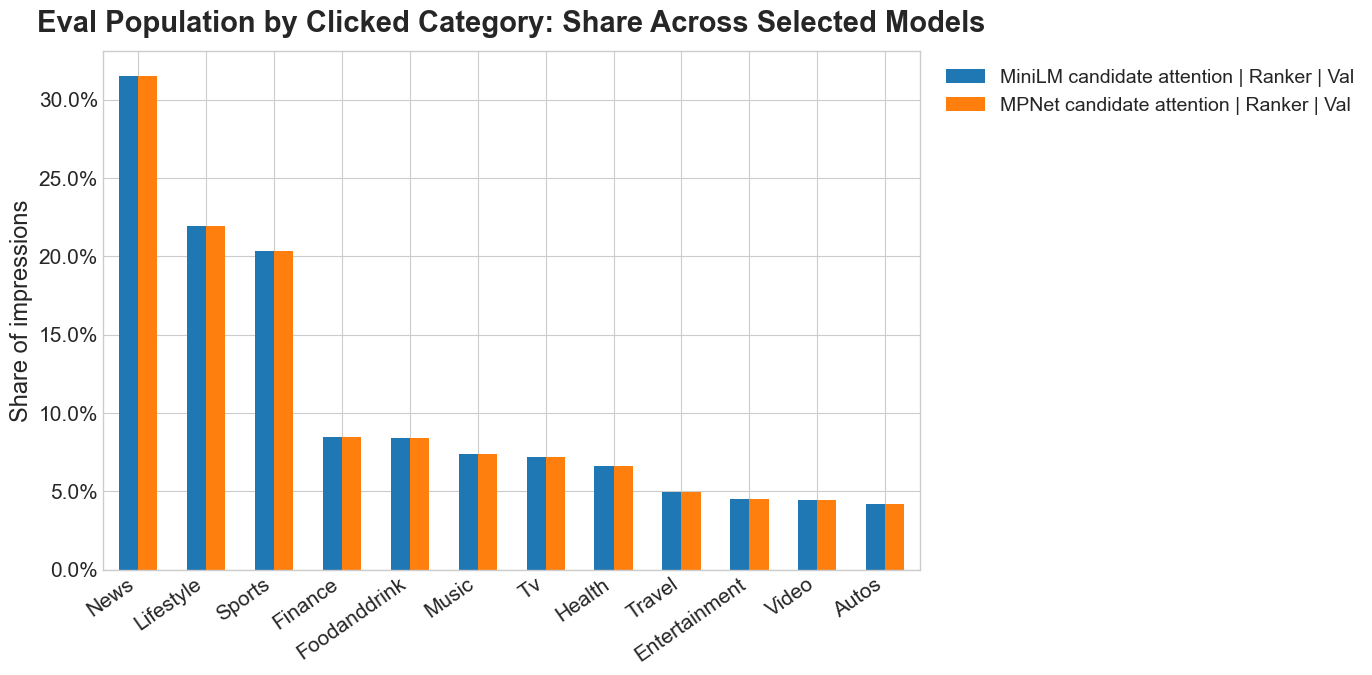

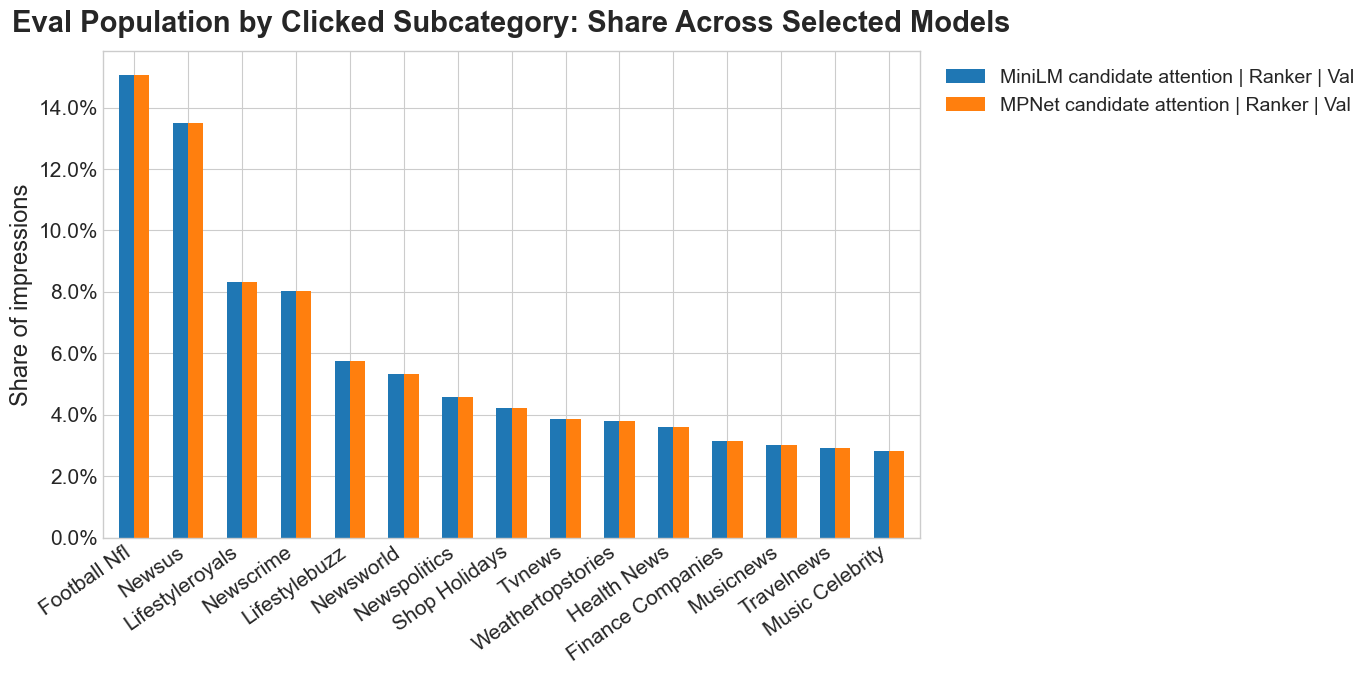

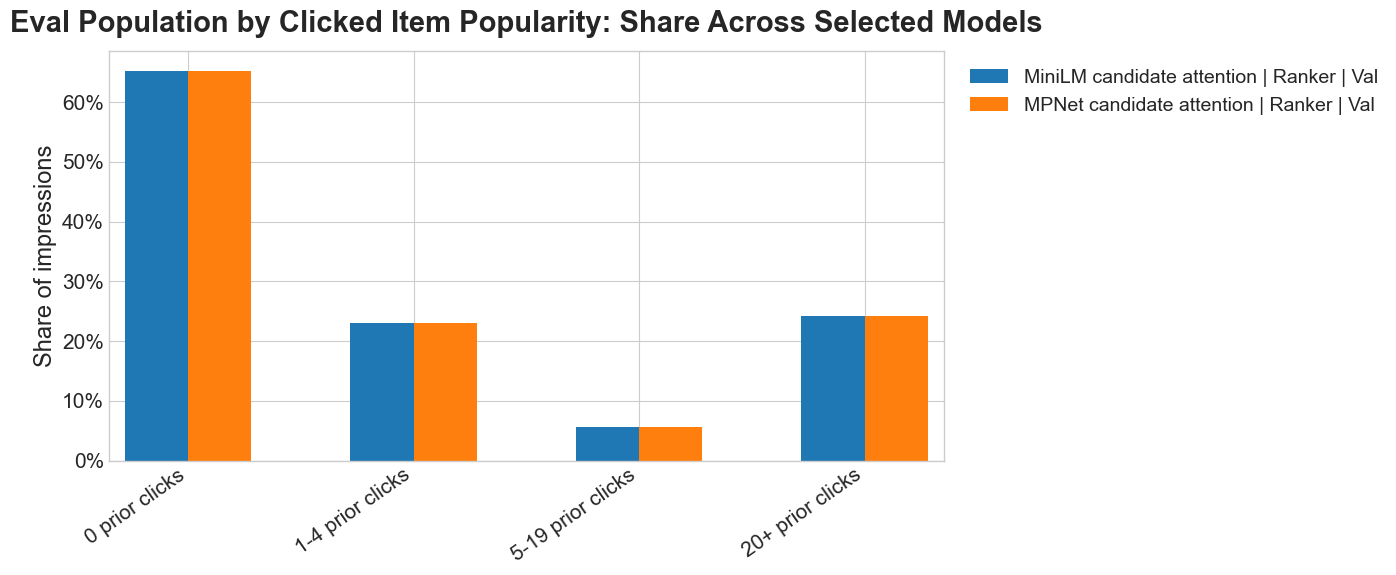

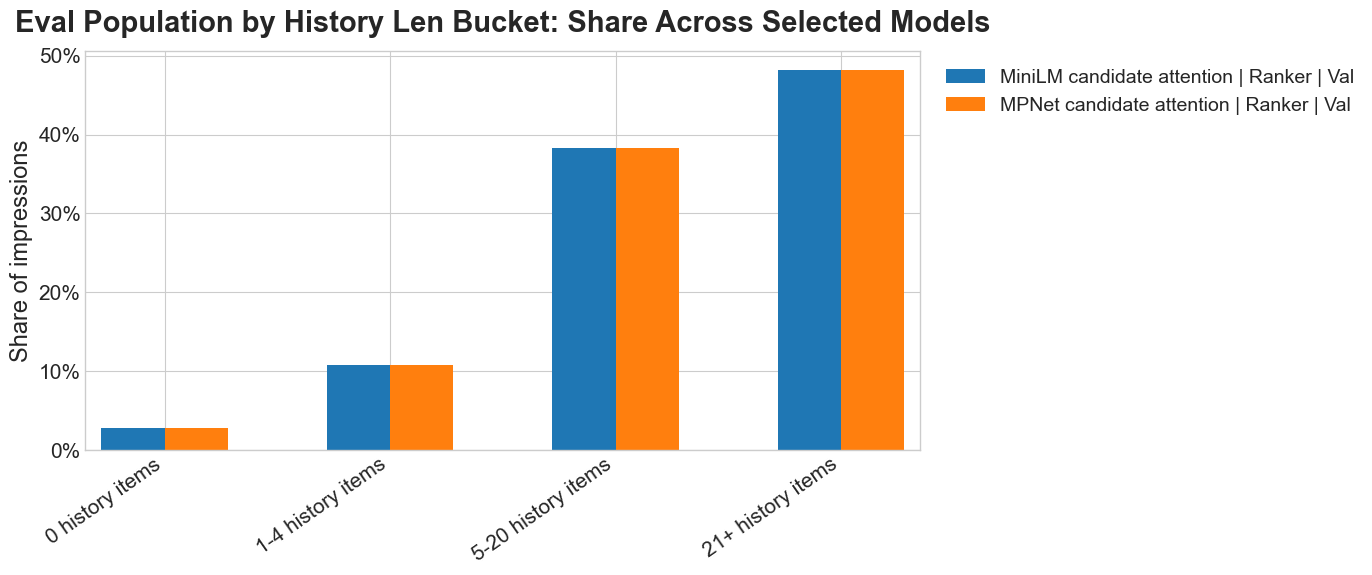

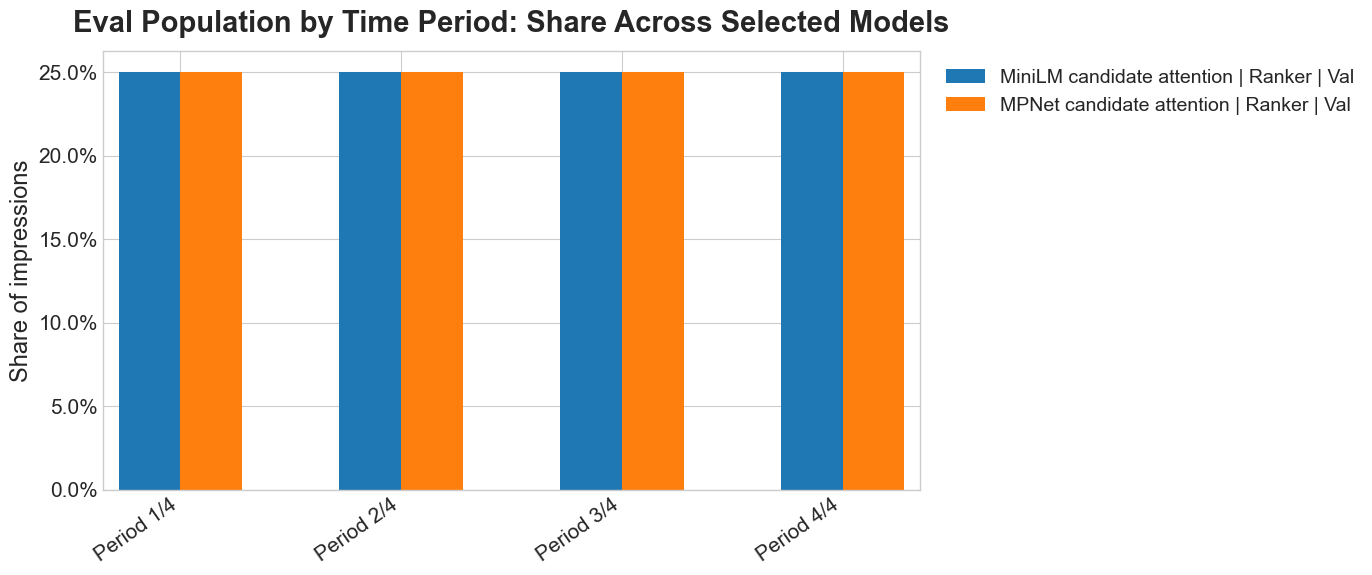

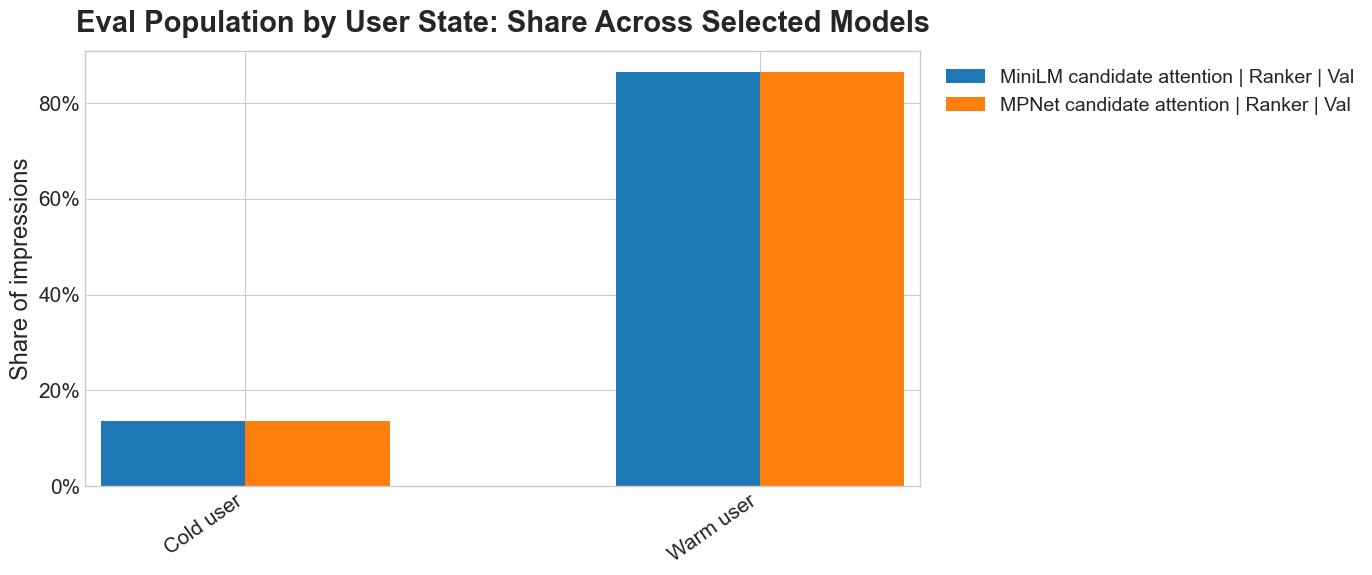

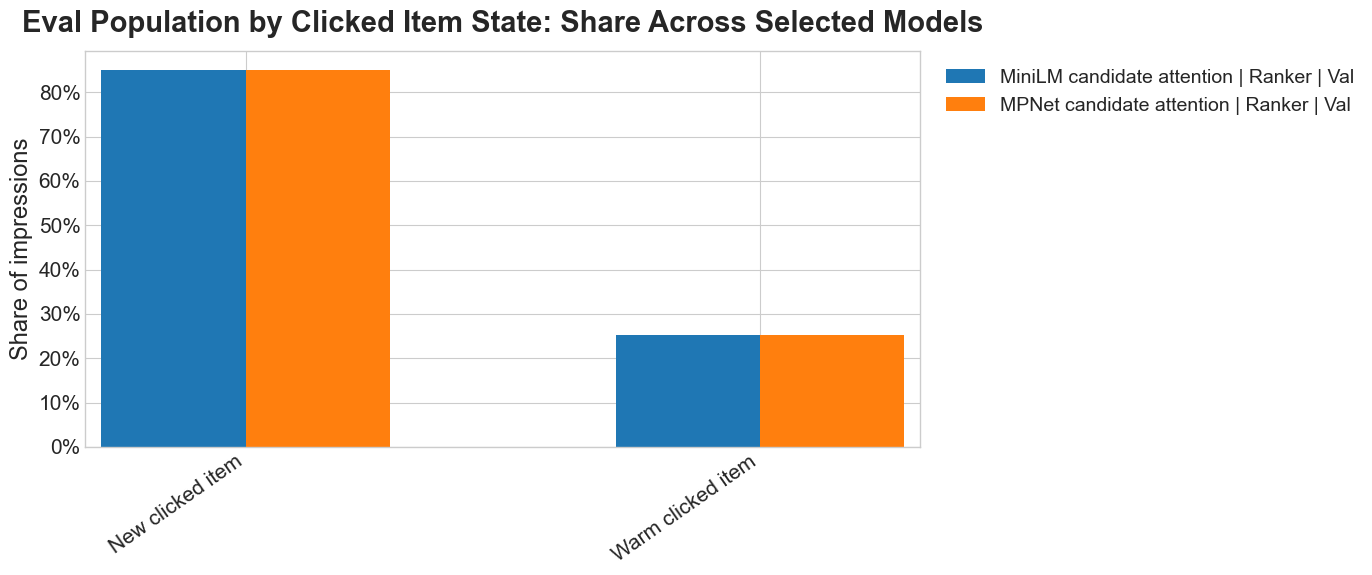

In [6]:
for dimension in SLICE_DIMENSIONS:
    plot_support_shares(dimension)

## Slice Performance

The next plots use whichever requested metrics are present in each selected JSON file. Ranker eval files commonly expose `ndcg@10`, `recall@10`, `auc`, and `mrr`; retrieval eval files expose `recall_at_k`.


Metric: AUC


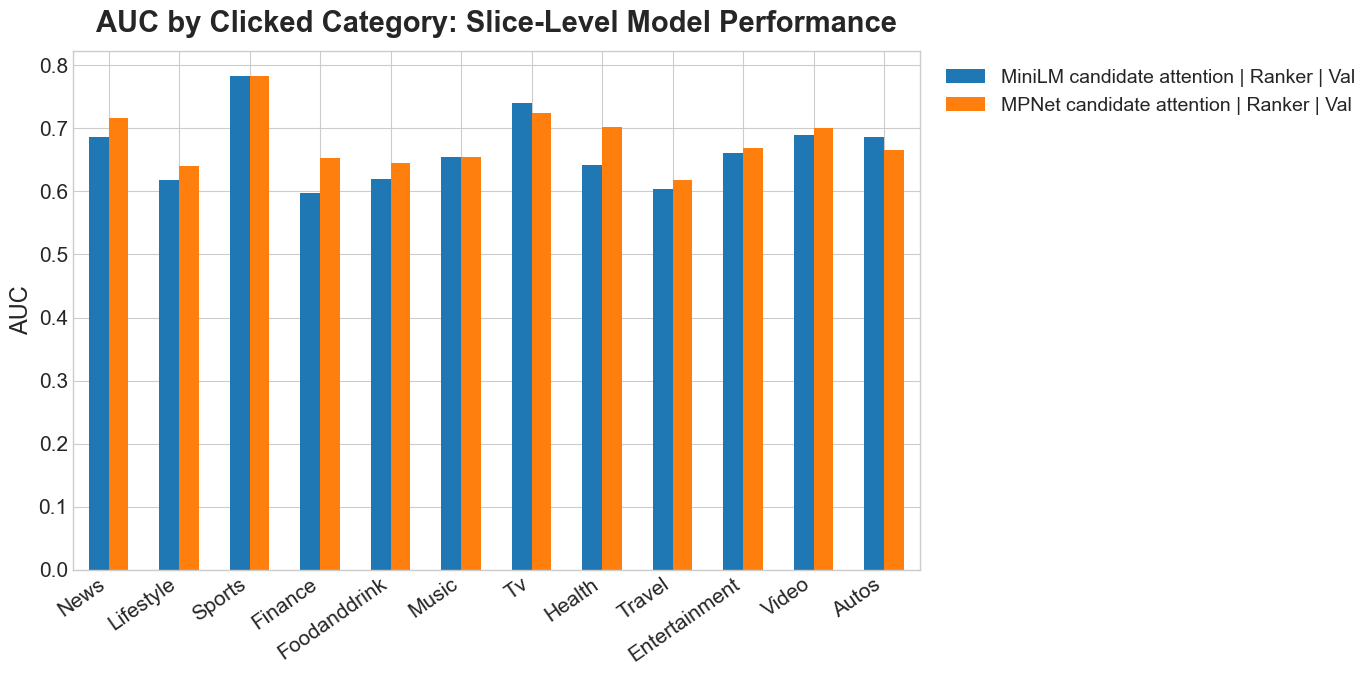

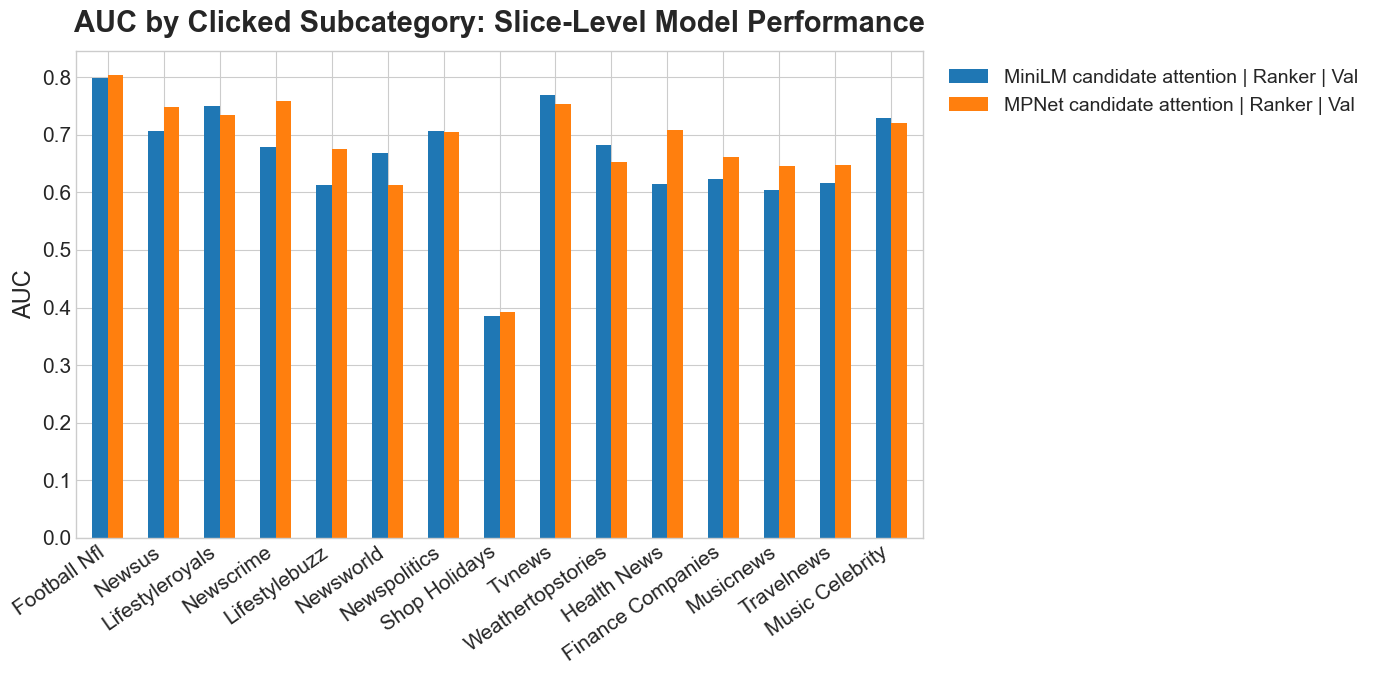

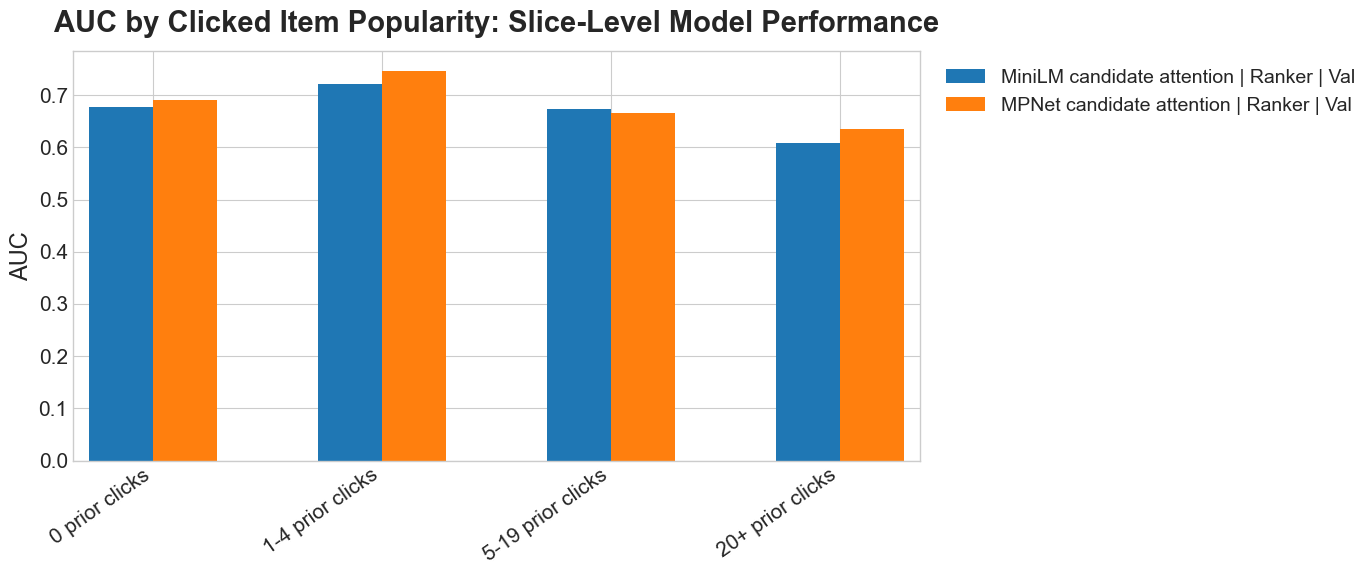

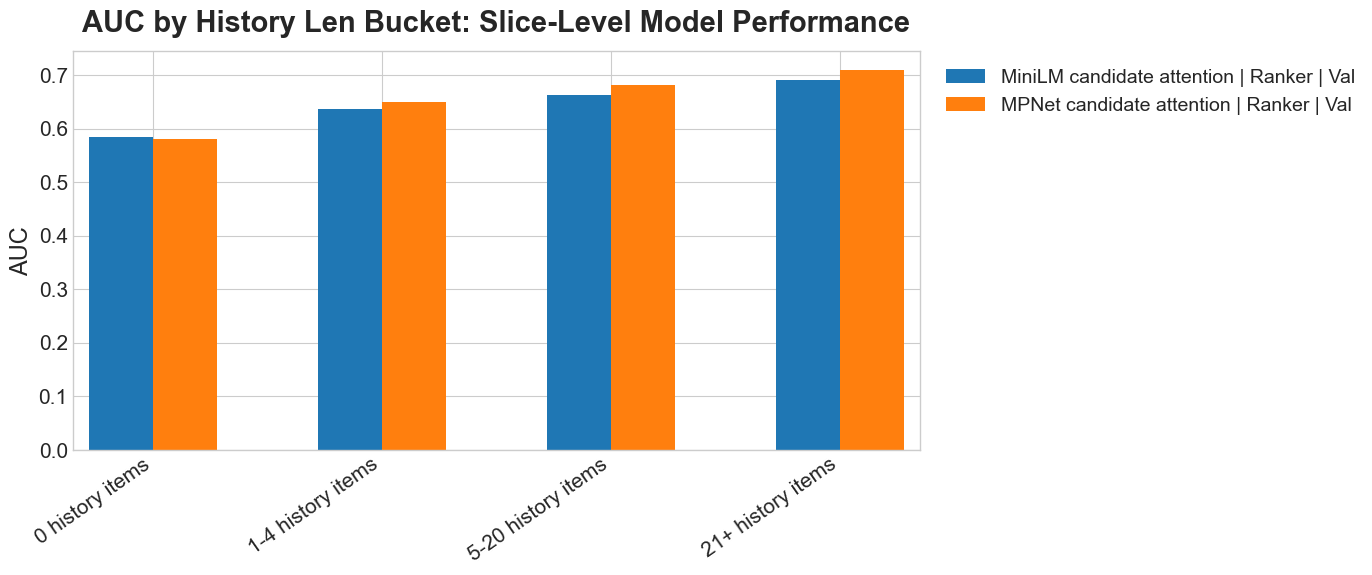

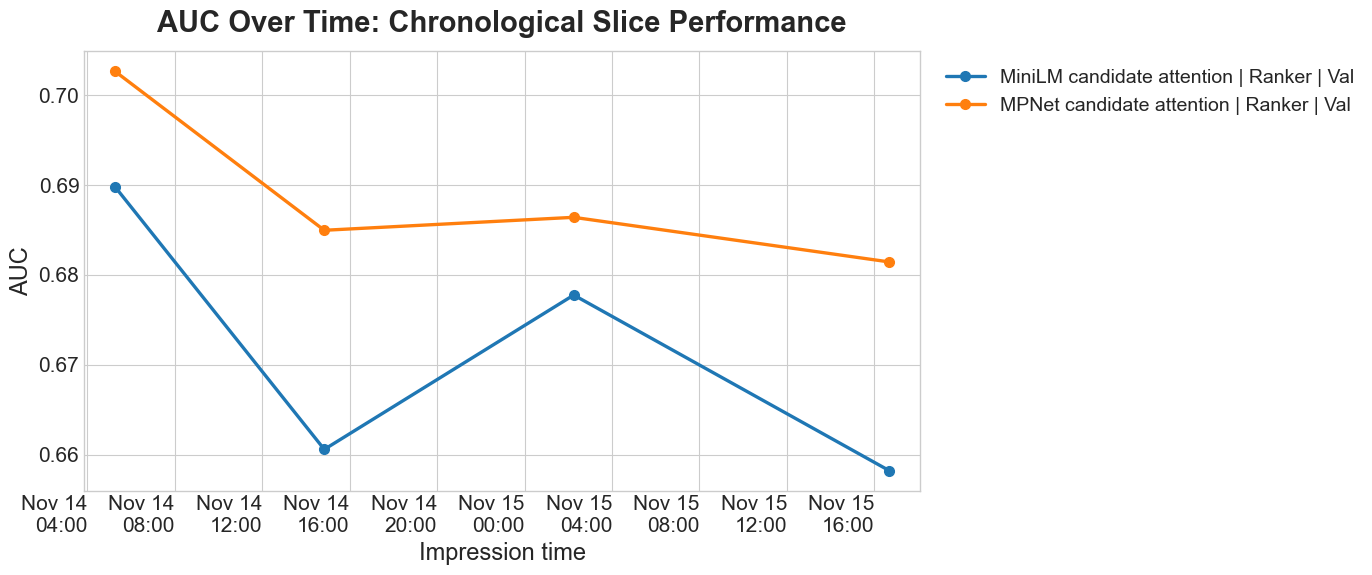

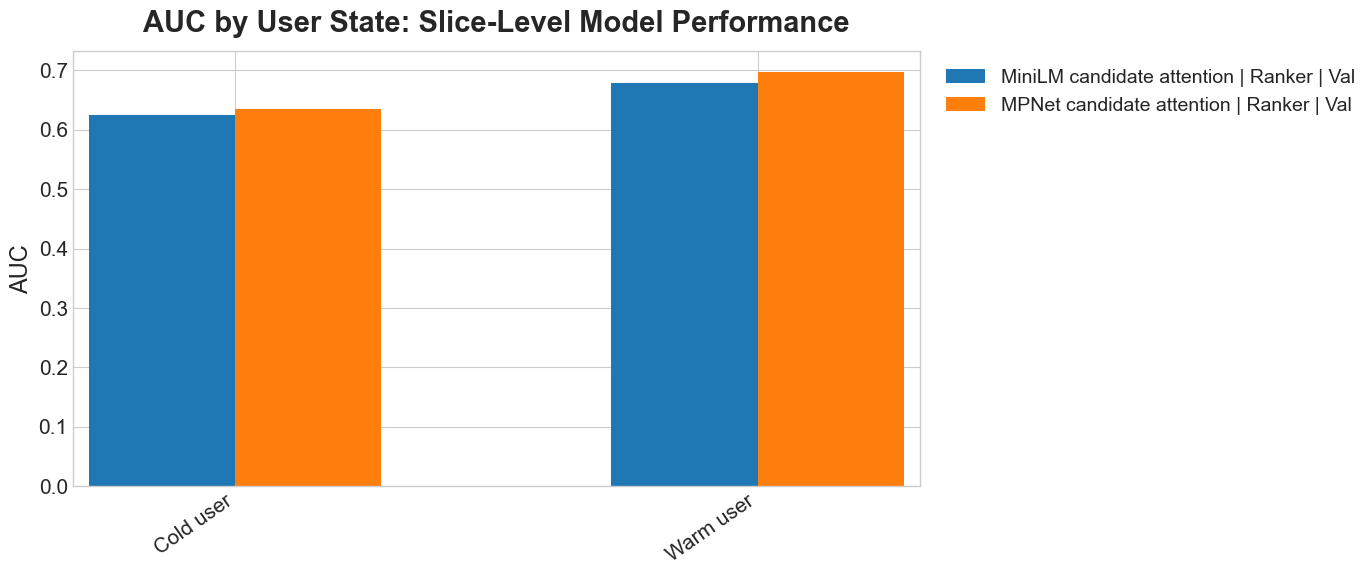

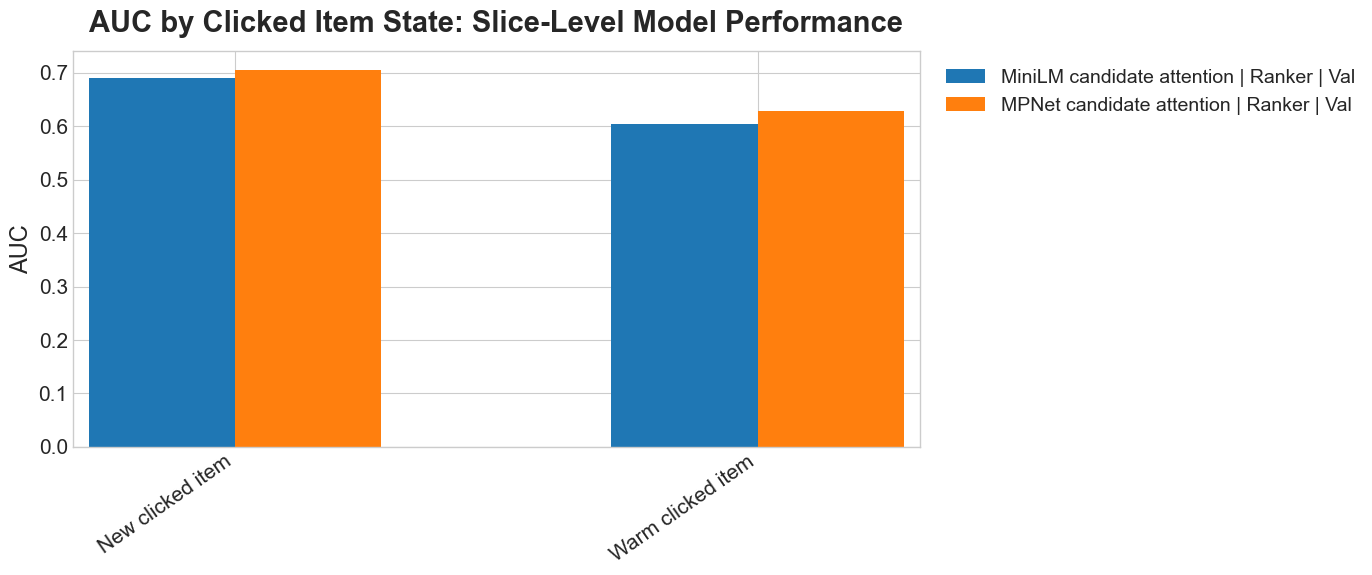


Metric: nDCG@10


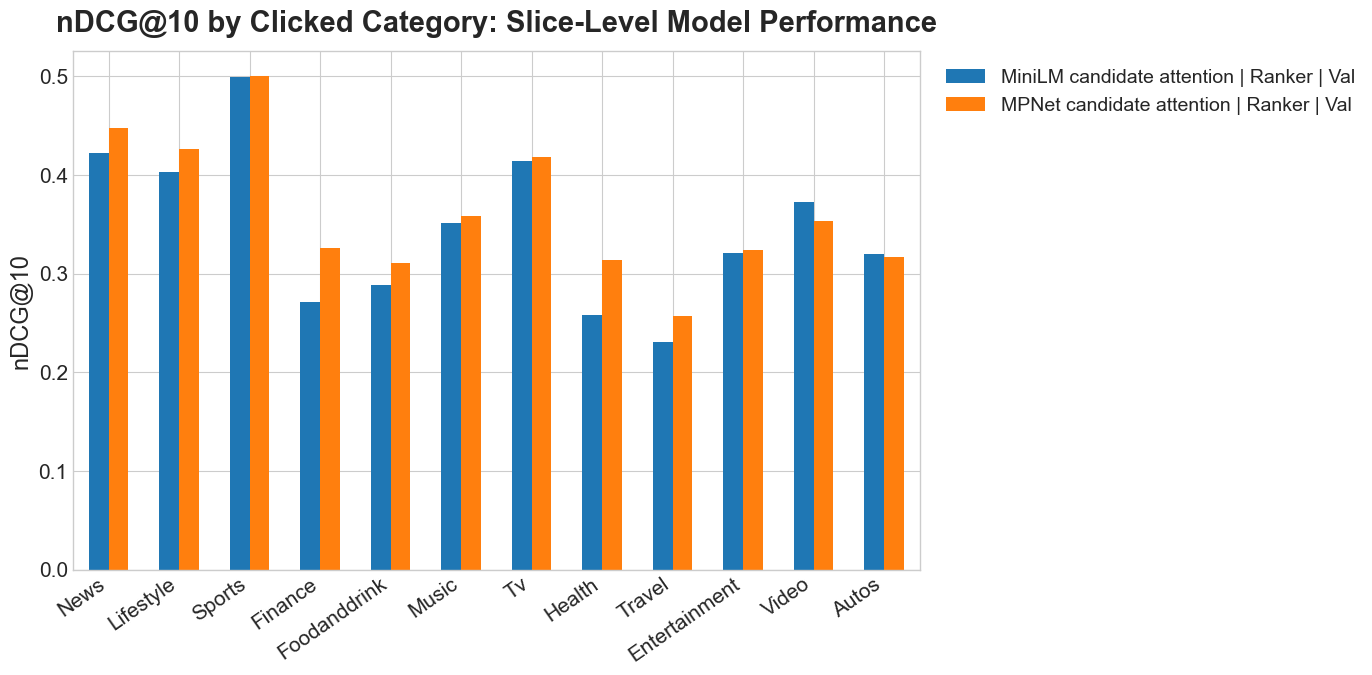

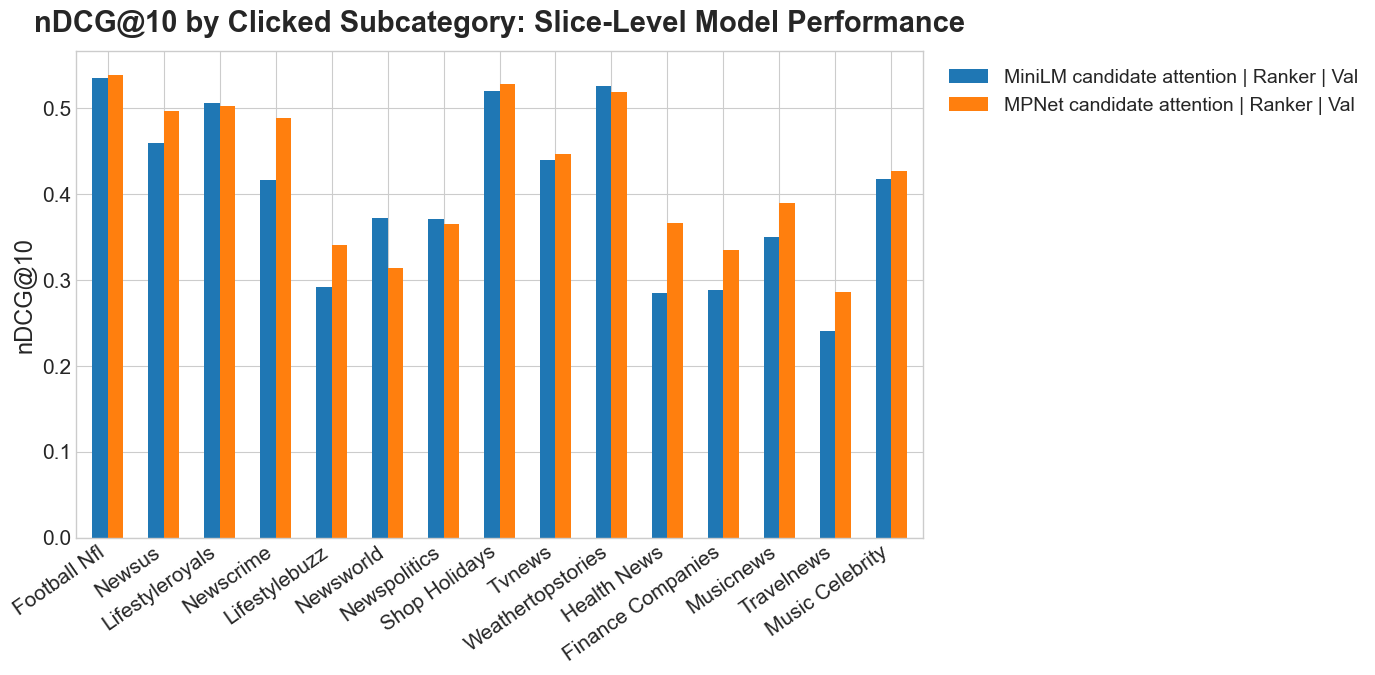

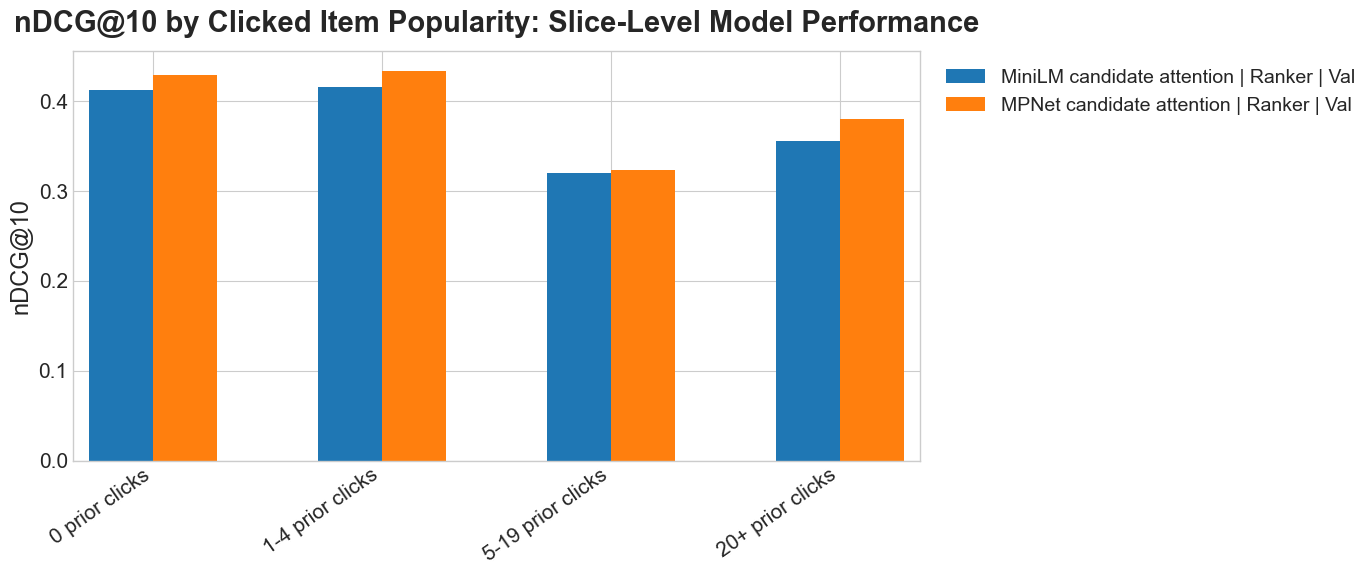

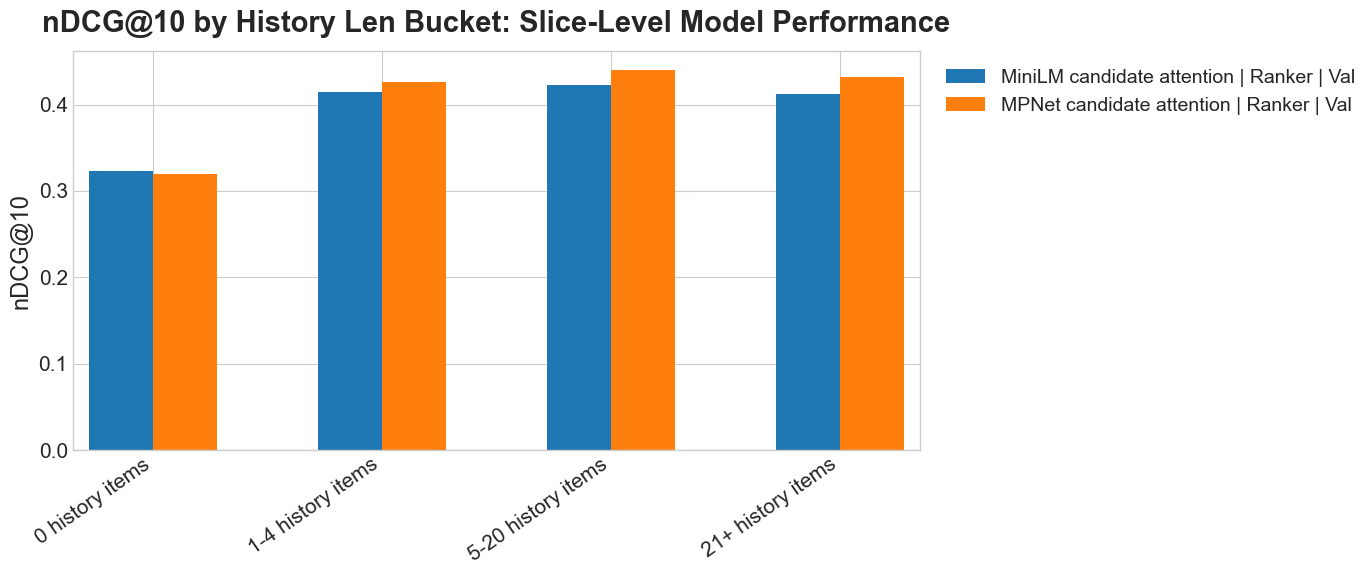

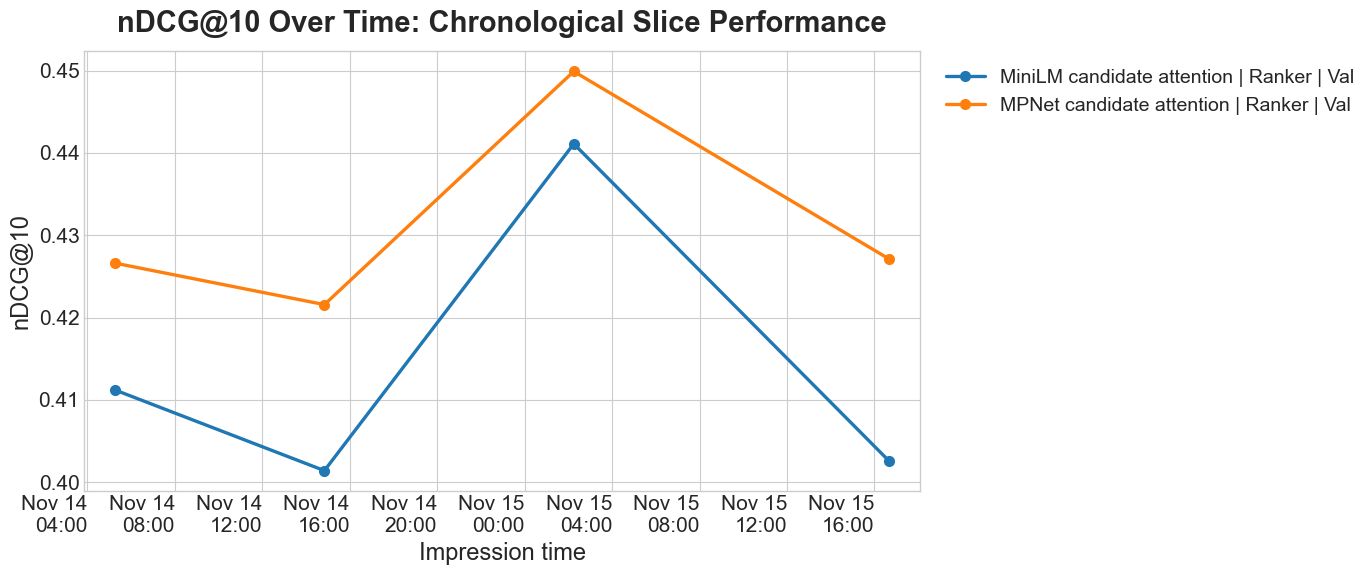

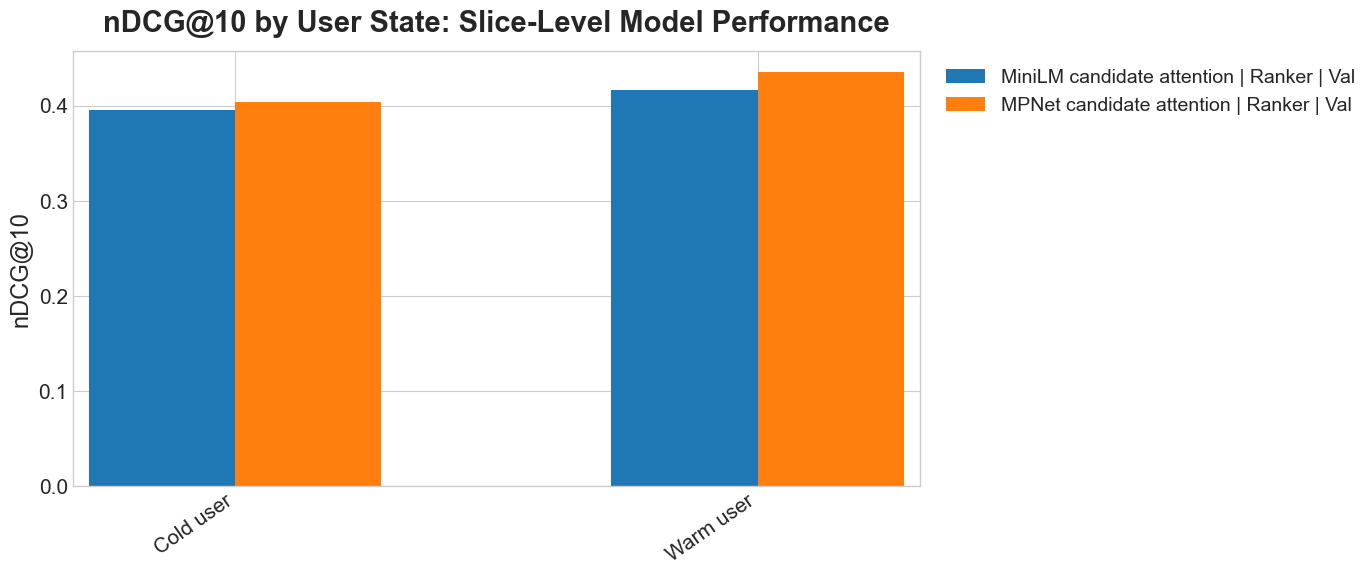

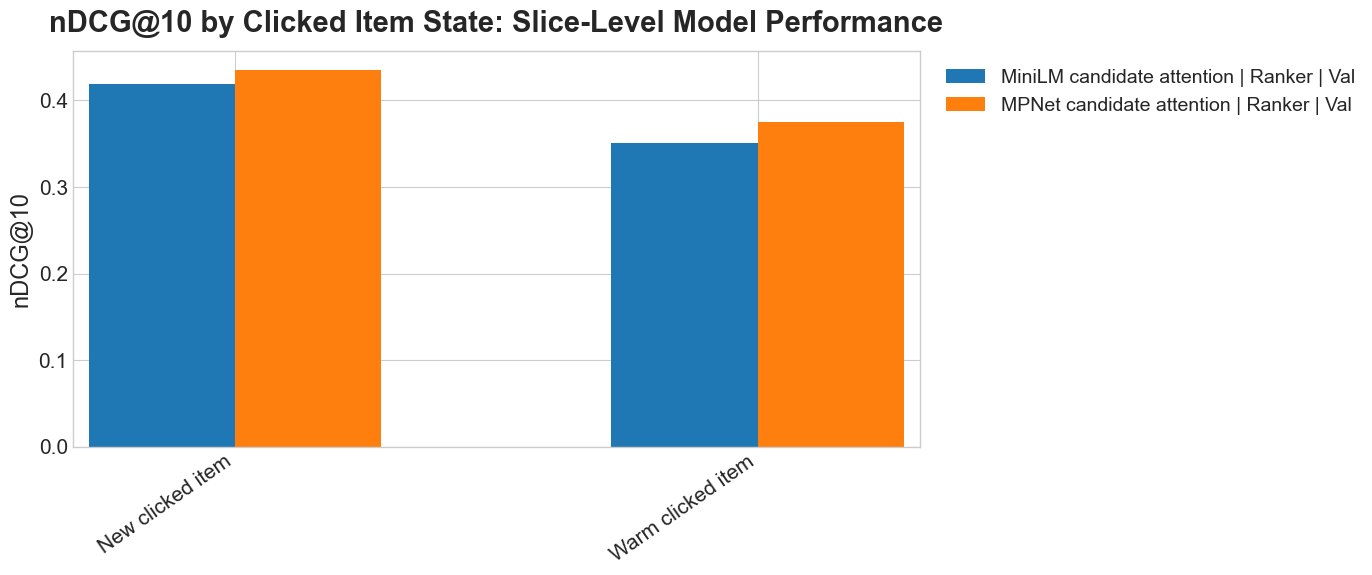

In [7]:
for metric in METRICS_TO_PLOT:
    if metric not in metric_cols:
        continue
    print(f"\nMetric: {metric_label(metric, slice_df)}")
    for dimension in SLICE_DIMENSIONS:
        plot_metric_by_dimension(dimension, metric)

## Highest And Lowest Slices

This table highlights slices that most deserve developer attention. Low-performing large slices are usually better debugging targets than tiny slices with noisy metrics.

In [8]:
summary_rows = []
for metric in METRICS_TO_PLOT:
    if metric not in metric_cols:
        continue
    data = slice_df[slice_df[metric].notna() & slice_df["n_impressions"].ge(MIN_IMPRESSIONS_FOR_METRIC_PLOTS)].copy()
    for file_label, group in data.groupby("file_label"):
        for dimension, dim_group in group.groupby("dimension"):
            n_extremes = min(3, max(1, len(dim_group) // 2))
            bottom = dim_group.nsmallest(n_extremes, metric)
            top = dim_group.drop(index=bottom.index).nlargest(n_extremes, metric)
            for tag, selected in [("lowest", bottom), ("highest", top)]:
                for _, row in selected.iterrows():
                    summary_rows.append({
                        "file_label": file_label,
                        "dimension": dimension,
                        "slice": pretty_value(row["value"], dimension),
                        "metric": metric_label(metric, selected),
                        "position": tag,
                        "value": row[metric],
                        "n_impressions": int(row["n_impressions"]),
                        "support_share": row["support_share"],
                    })

attention_table = pd.DataFrame(summary_rows).sort_values(["metric", "file_label", "dimension", "position", "value"])
display(attention_table)

,file_label,dimension,slice,metric,position,value,n_impressions,support_share
5,MPNet candidate attention | Ranker | Val,clicked_category,News,AUC,highest,0.716860,254611,0.315117
4,MPNet candidate attention | Ranker | Val,clicked_category,Tv,AUC,highest,0.724854,58139,0.071955
3,MPNet candidate attention | Ranker | Val,clicked_category,Sports,AUC,highest,0.782783,164211,0.203234
0,MPNet candidate attention | Ranker | Val,clicked_category,Movies,AUC,lowest,0.584000,33294,0.041206
1,MPNet candidate attention | Ranker | Val,clicked_category,Travel,AUC,lowest,0.617869,40187,0.049737
...,...,...,...,...,...,...,...,...
108,MiniLM candidate attention | Ranker | Val,time_period,Period 3/4,nDCG@10,highest,0.441096,201997,0.250000
106,MiniLM candidate attention | Ranker | Val,time_period,Period 2/4,nDCG@10,lowest,0.401410,201997,0.250000
107,MiniLM candidate attention | Ranker | Val,time_period,Period 4/4,nDCG@10,lowest,0.402559,201997,0.250000
111,MiniLM candidate attention | Ranker | Val,user_state,Warm user,nDCG@10,highest,0.416986,698541,0.864544
